In [62]:
import csv
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ogmios.dataset.aligments import AlignmentFile
from ogmios.dataset.commons import DatasetFolder


def get_random_file(folder: Path):
    return random.choice(list(folder.iterdir()))


lj_path = Path("../data/LJSpeech-1.1/preprocessed/pitch/pitch-LJ001-0002.npy")
mls_24h_path = Path("../data/mls_24h/preprocessed/pitch/1817_1028_000009.npy")

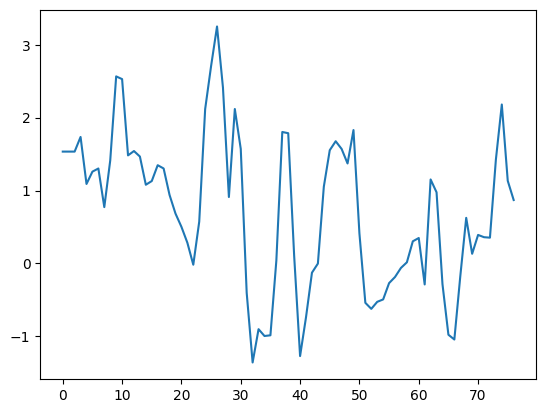

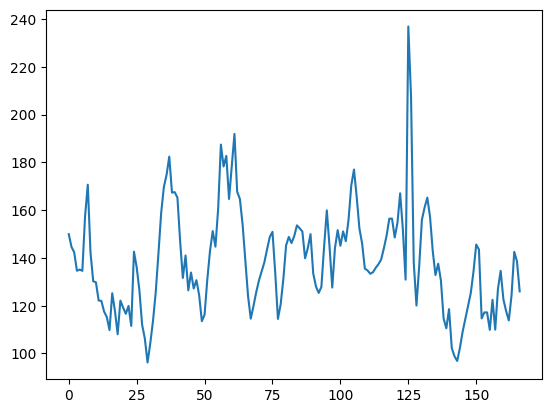

In [13]:
plt.plot(np.load(get_random_file(Path("../data/LJSpeech-1.1/preprocessed/pitch/"))))
plt.show()
plt.plot(np.load(get_random_file(Path("../data/mls_24h/preprocessed/pitch/"))))
plt.show()

['m', 'a', 'k', 'd', 'ɔ', 'n', 'a', 'ɫ', 's', 't', 'ɹ', 'ɐ', 'k', 'b', 'a', 'k', 'ʋ', 'ɪ', 'd̪', 'ç', 'i', 'z', 'ɹ', 'aj', 'sil', 'h', 'a', 'n', 'd', 'sil', 'a', 'n', 'ɡ', 'ɹ', 'a', 'b', 'd', 'ð', 'a', 'ɡ', 'ɐ', 'n', 'ʋ', 'ɪ', 'd̪', 'ç', 'i', 'z', 'l', 'ɛ', 'f', 't', 'h', 'a', 'n', 'd', 'sil', 'ð', 'e', 'b', 'əw', 'θ', 'f', 'ɛ', 'l', 'ɪ', 'n', 'ʈ', 'ʉː', 'ð', 'a', 's', 'iː', 't', 's']


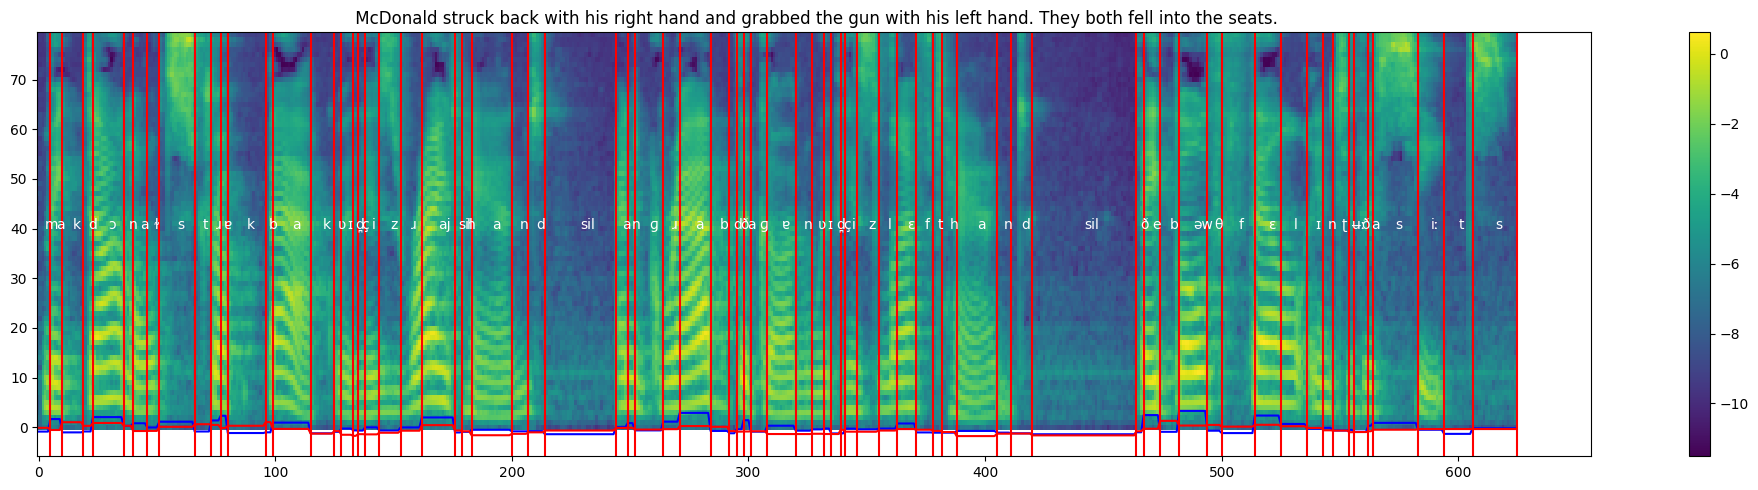

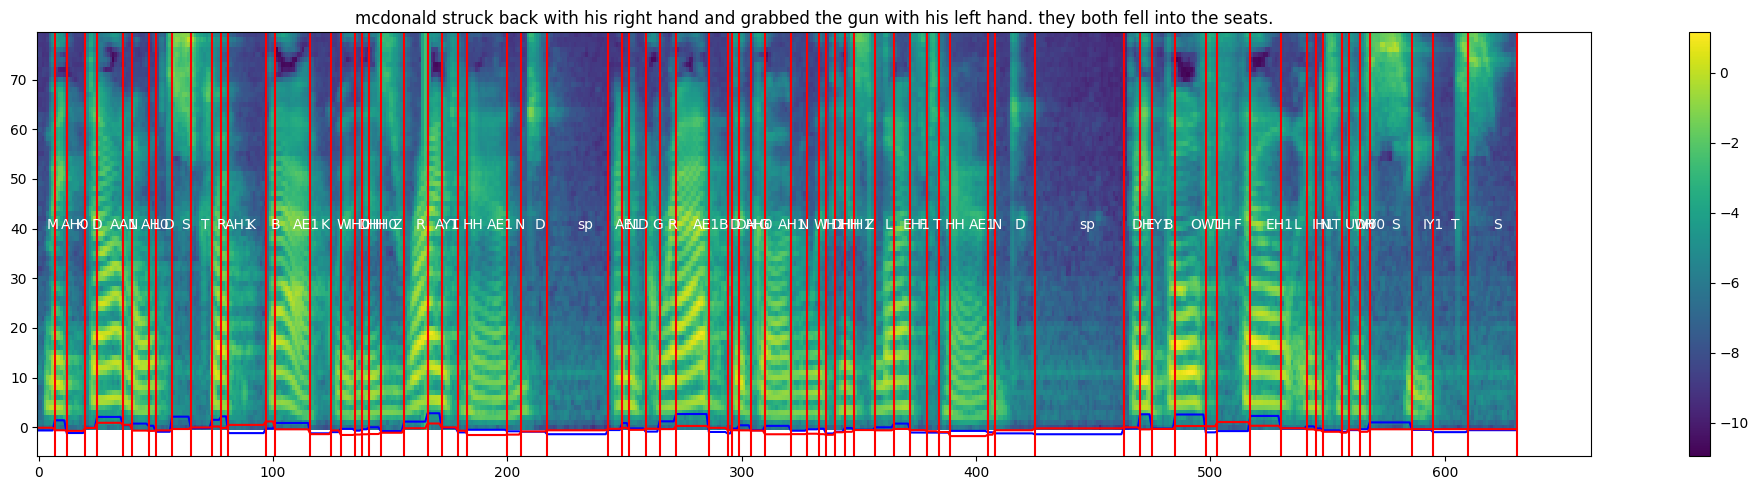

In [72]:
def show_preprocessed_sample(dataset: DatasetFolder, sample_id: str):
    phones, transcript = None, None
    with open(dataset.preprocessed_folder / "metadata.csv", "r") as f:
        csv_reader = csv.reader(f, delimiter="\t")
        for row in csv_reader:
            if row[0] == sample_id:
                phones = row[1].split("|")
                trans = row[2]

    print(phones)
    mel = np.load(dataset.mels_folder / f"{sample_id}.npy")
    pitch = np.load(dataset.pitches_folder / f"{sample_id}.npy")
    energy = np.load(dataset.energies_folder / f"{sample_id}.npy")
    duration = np.load(dataset.durations_folder / f"{sample_id}.npy")

    mel = mel.T
    pitch = np.repeat(pitch, duration)
    energy = np.repeat(energy, duration)

    plt.figure(1, figsize=(20, 5))
    plt.imshow(mel, aspect="auto", origin="lower",
               interpolation='none')
    plt.colorbar()
    plt.plot(energy, color="blue")
    plt.plot(pitch, color="red")

    for x, dur, phone in zip(np.cumsum(duration), duration, phones):
        plt.axvline(x=x, color='r')
        plt.text(x=x - (dur / 2), y=80 / 2, s=phone, color="white")

    plt.title(trans)
    plt.tight_layout()
    plt.show()


def show_preprocess_sample_old_format(dataset: Path, sample_id: str):
    phones, trans = None, None
    pp_folder = dataset / "preprocessed"
    with open(pp_folder / "train.txt", "r") as f:
        csv_reader = csv.reader(f, delimiter="|")
        for row in csv_reader:
            if row[0] == sample_id:
                phones = row[1][1:-1].split(" ")
                trans = row[2]
    if phones is None:
        with open(pp_folder / "val.txt", "r") as f:
            csv_reader = csv.reader(f, delimiter="|")
            for row in csv_reader:
                if row[0] == sample_id:
                    phones = row[1][1:-1].split(" ")
                    trans = row[2]

    mel = np.load(pp_folder / "mel" / f"mel-{sample_id}.npy")
    pitch = np.load(pp_folder / "pitch" / f"pitch-{sample_id}.npy")
    energy = np.load(pp_folder / "energy" / f"energy-{sample_id}.npy")
    duration = np.load(pp_folder / "duration" / f"duration-{sample_id}.npy")

    mel = mel.T
    pitch = np.repeat(pitch, duration)
    energy = np.repeat(energy, duration)

    plt.figure(1, figsize=(20, 5))
    plt.imshow(mel, aspect="auto", origin="lower",
               interpolation='none')
    plt.colorbar()
    plt.plot(energy, color="blue")
    plt.plot(pitch, color="red")

    for x, dur, phone in zip(np.cumsum(duration), duration, phones):
        plt.axvline(x=x, color='r')
        plt.text(x=x - (dur / 2), y=80 / 2, s=phone, color="white")

    plt.title(trans)
    plt.tight_layout()
    plt.show()


def get_random_sample(dataset: DatasetFolder) -> str:
    return random.choice(list(dataset.wavs_folder.iterdir())).stem


ds = DatasetFolder(Path("../data/ljspeech/"))
old_ds = Path("../data/LJSpeech-1.1/")
sample = get_random_sample(ds)
show_preprocessed_sample(ds, sample)
show_preprocess_sample_old_format(old_ds, sample)

In [68]:
ds_fr = DatasetFolder(Path("../data/5232_6h/"))
sample = get_random_sample(ds_fr)
with open(ds_fr.alignments_folder / "spk1" / f"{sample}.json") as f:
    alignment = AlignmentFile(**json.load(f))

def pairwise(iterable):
    "s -> (s0, s1), (s2, s3), (s4, s5), ..."
    a = iter(iterable)
    return zip(a, a)

for a, b in pairwise(alignment.phones.intervals):
    if a.end != b.start:
        print(a, "||", b)
    

start=3.17 end=3.3 annot='e' || start=3.62 end=3.7 annot='ɛ'
start=4.52 end=4.67 annot='d' || start=5.05 end=5.09 annot='p'
start=7.8 end=7.95 annot='ɛ' || start=8.31 end=8.38 annot='t'


['ɛ', 'l', 'e', 't', 'ɛ', 's', 'i', 'sil', 'i', 'ɲ', 'ɔ', 'ʁ', 'ɑ̃', 't', 'c', 'ɛ', 'l', 'm', 'ə', 'f', 'ə', 'z', 'ɛ', 't', 'ʁ', 'ɑ̃', 'b', 'l', 'e', 'sil', 'e', 'ʁ', 'u', 'ʒ', 'i', 'ʁ', 'sil', 't', 'u', 't', 'l', 'e', 'f', 'w', 'a', 'sil', 'c', 'ɛ', 'l', 'u', 'v', 'ʁ', 'ɛ', 'sil', 'l', 'a', 'b', 'u', 'ʃ', 'd', 'a', 'j', 'œ', 'ʁ', 'sil', 'ɛ', 'l', 'a', 'v', 'ɛ', 'sil', 't', 'u', 'l', 'e', 'd', 'e', 'f', 'o', 'd', 'e', 's', 'ɔ', 't']


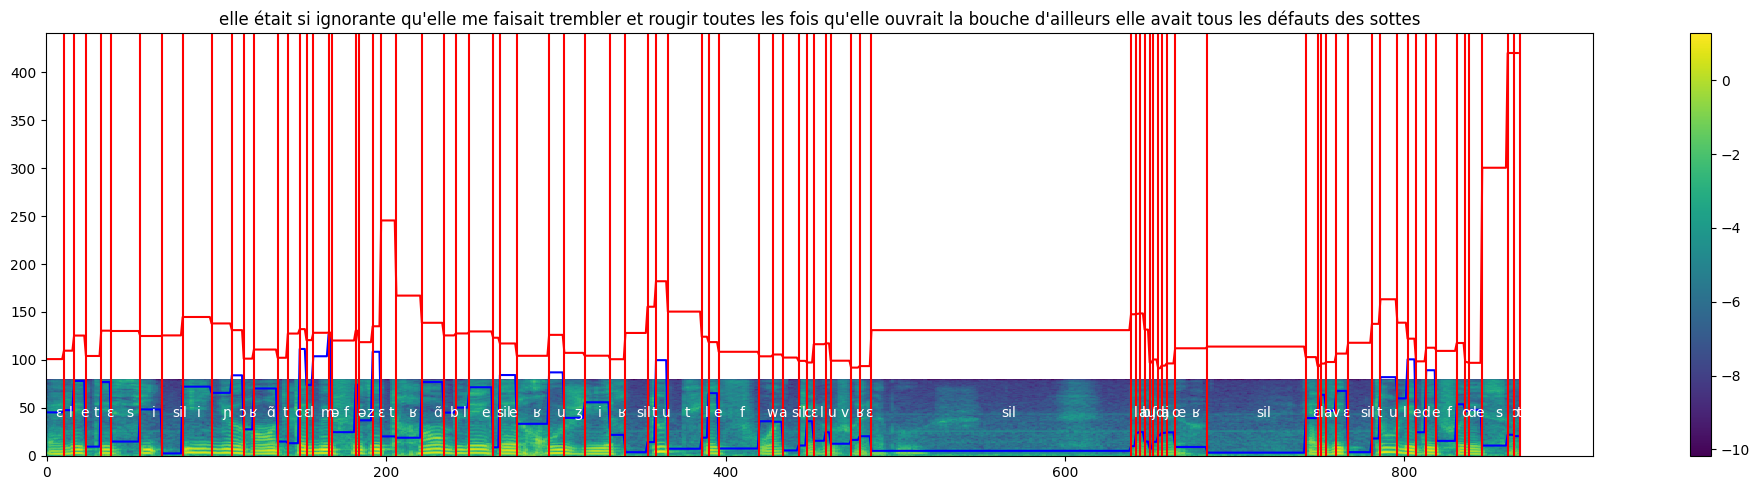

In [74]:
ds = DatasetFolder(Path("../data/mls_24h/"))
sample = get_random_sample(ds)
show_preprocessed_sample(ds, sample)